In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

count_sub = metadata_20x_filt.loc[~metadata_20x_filt.cov_chrX.isna()][["gSEX", "group", "species_genotyping", "species"]].value_counts().reset_index()
used_species = count_sub.loc[(count_sub.gSEX == "F") | ((count_sub.gSEX == "M") & (count_sub["count"] >= 2))].species_genotyping.unique()

In [3]:
metadata_20x_filt.family.unique()

array(['Cercopithecidae', 'Aotidae', 'Atelidae', 'Callitrichidae',
       'Tarsiidae', 'Cheirogaleidae', 'Daubentoniidae', 'Lemuridae',
       'Hominidae', 'Hylobatidae', 'Lepilemuridae', 'Lorisidae',
       'Galagidae', 'Pitheciidae', 'Indriidae', 'Cebidae'], dtype=object)

In [4]:
df_l = []
for s in used_species:
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    if sum(pi_df.chr_type == "chrX") < 10 or sum(pi_df.chr_type == "aut") < 10:
        print("Too little data", s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [5]:
len(all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (~all_pi_df.pi.isna())].species.unique())

193

In [6]:
chrX_pi = all_pi_df.loc[(all_pi_df.chr_type == "chrX") & (~all_pi_df.pi.isna())]

Determining cutoff for the callable fraction parameter, which determines how large of proportion of the window should be accessible for base calling before passing the filtering step.
Focus is on chrX performance, as the assembly for chromosome X varies more in how good it is.

<Axes: xlabel='callable_frac', ylabel='Count'>

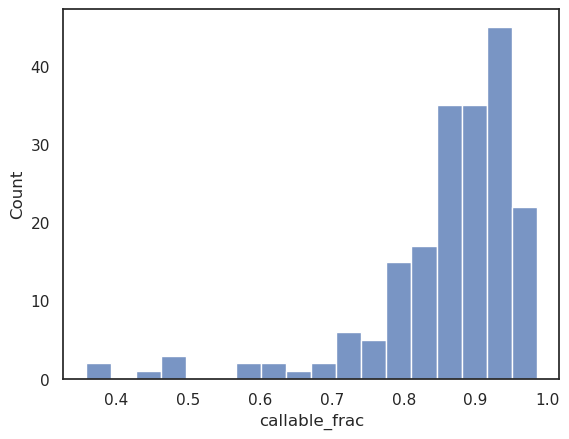

In [7]:
# Most species have a good average callability, but that is actually not the most interesting statistic.
mean_callable = chrX_pi.groupby(["species"])[["callable_frac"]].mean().sort_values(by="callable_frac")
sns.histplot(mean_callable, x="callable_frac")

<Axes: xlabel='callable_frac', ylabel='Count'>

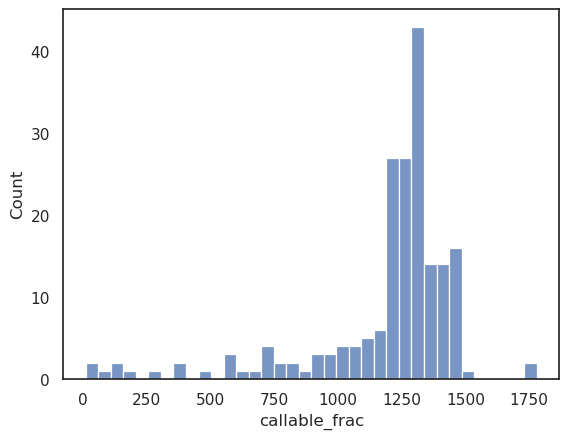

In [8]:
# Instead we can check how many windows pass the filter.
count_callable = chrX_pi.loc[chrX_pi.callable_frac >= 0.75].groupby(["species"])[["callable_frac"]].count().sort_values(by="callable_frac")
sns.histplot(count_callable, x="callable_frac")

<Axes: xlabel='callable_frac', ylabel='Count'>

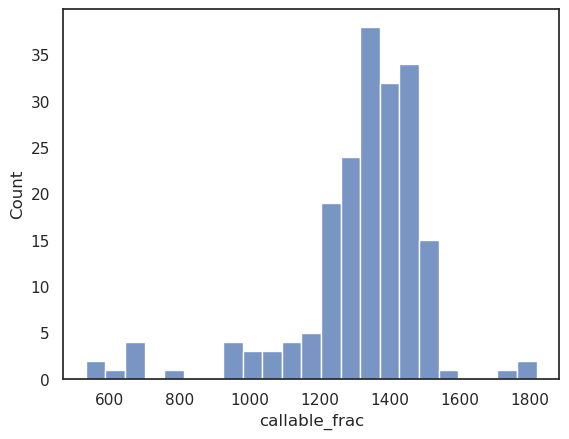

In [9]:
# Allowing for 50 % makes even the worst performers contain roughly 600 windows (or 60Mb).
count_callable = chrX_pi.loc[chrX_pi.callable_frac >= 0.5].groupby(["species"])[["callable_frac"]].count().sort_values(by="callable_frac")
sns.histplot(count_callable, x="callable_frac")

<Axes: xlabel='callable_frac', ylabel='Count'>

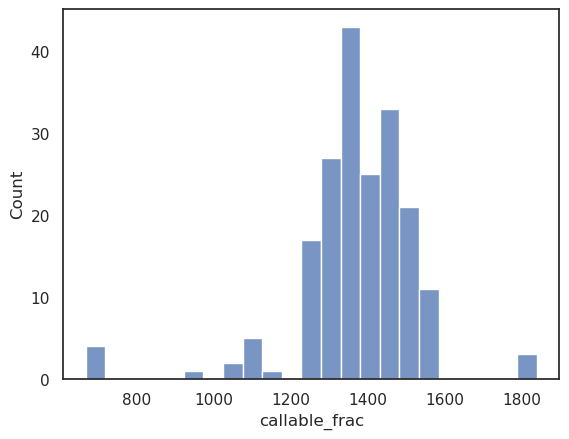

In [10]:
# This is probably too generous
count_callable = chrX_pi.loc[chrX_pi.callable_frac >= 0.25].groupby(["species"])[["callable_frac"]].count().sort_values(by="callable_frac")
sns.histplot(count_callable, x="callable_frac")

In [11]:
# Checking the worst performers.
mean_callable

,callable_frac
species,
Arctocebus_calabarensis_ssp,0.357284
Perodicticus_potto_ssp,0.363138
Lepilemur_septentrionalis_ssp,0.455399
Loris_lydekkerianus_ssp,0.465861
Loris_tardigradus_ssp,0.477096
...,...
Callimico_goeldii_ssp,0.978899
Otolemur_crassicaudatus_ssp,0.981602
Daubentonia_madagascariensis_ssp,0.982396


<Axes: xlabel='callable_frac', ylabel='Count'>

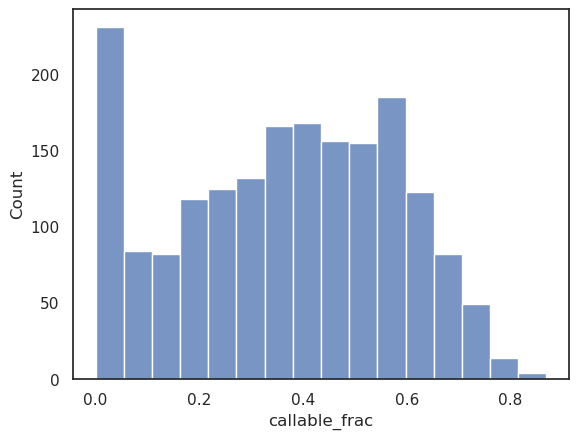

In [12]:
sns.histplot(chrX_pi.loc[chrX_pi.species == "Perodicticus_potto_ssp"], x="callable_frac")

In [13]:
count_callable50 = chrX_pi.loc[chrX_pi.callable_frac >= 0.5].groupby(["species"])[["callable_frac"]].count().sort_values(by="callable_frac")
count_callable50

,callable_frac
species,
Arctocebus_calabarensis_ssp,533
Perodicticus_potto_ssp,583
Hapalemur_meridionalis_ssp,639
Prolemur_simus_ssp,645
Hapalemur_griseus_ssp,646
...,...
Rhinopithecus_roxellana_ssp,1533
Nasalis_larvatus_ssp,1554
Xanthonycticebus_pygmaeus_ssp,1726


In [14]:
species_list = count_callable50.loc[count_callable50.callable_frac >= 200].index
len(species_list)

193

In [15]:
species_list

Index(['Arctocebus_calabarensis_ssp', 'Perodicticus_potto_ssp',
       'Hapalemur_meridionalis_ssp', 'Prolemur_simus_ssp',
       'Hapalemur_griseus_ssp', 'Lemur_catta_ssp',
       'Lepilemur_septentrionalis_ssp', 'Lepilemur_ankaranensis_ssp',
       'Avahi_peyrierasi_ssp', 'Varecia_variegata_ssp',
       ...
       'Macaca_cyclopis_ssp', 'Macaca_mulatta_ssp',
       'Rhinopithecus_strykeri_ssp', 'Colobus_guereza_ssp',
       'Rhinopithecus_bieti_ssp', 'Rhinopithecus_roxellana_ssp',
       'Nasalis_larvatus_ssp', 'Xanthonycticebus_pygmaeus_ssp',
       'Nycticebus_coucang_ssp', 'Nycticebus_bengalensis_ssp'],
      dtype='object', name='species', length=193)

Removing all windows with less than 50 % callable

In [16]:
filt_pi_df = all_pi_df.loc[all_pi_df.callable_frac >= 0.5]

[Text(0.5, 1.0, 'Mean across species'),
 (-0.0001, 0.007020954500875656),
 (-0.0001, 0.004356546228710463)]

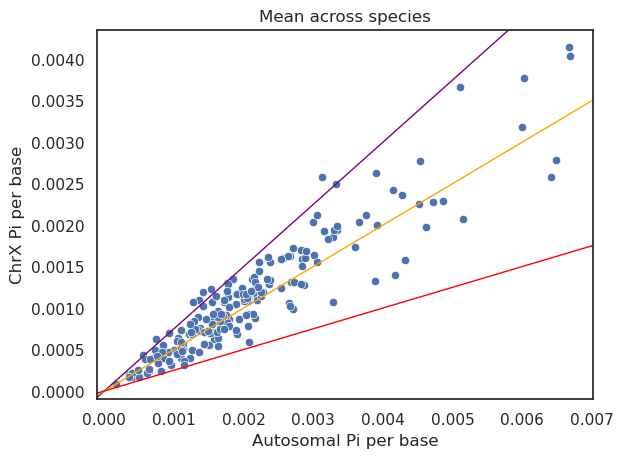

In [17]:
mean_pi_df = filt_pi_df.groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df = mean_pi_df.reset_index()
plt.axline((0, 0), slope=0.75, linewidth=1, color='purple')
plt.axline((0, 0), slope=0.5, linewidth=1, color='orange')
plt.axline((0, 0), slope=0.25, linewidth=1, color='red')
g = sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="ChrX Pi per base")
g.set(title="Mean across species", xlim=(-0.0001, None), ylim=(-0.0001, None))

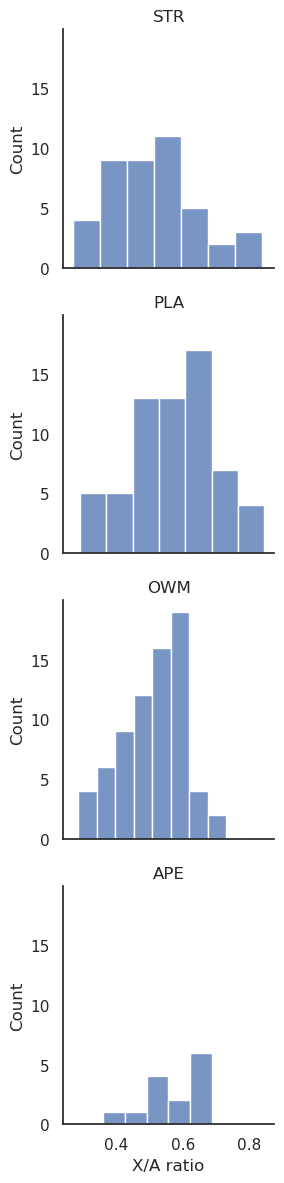

In [18]:
mean_pi_df["Group"] = mean_pi_df.species.map(dict(zip(metadata_20x_filt.species_genotyping, metadata_20x_filt.group)))
g = sns.FacetGrid(mean_pi_df.loc[mean_pi_df.Group.isin(["OWM", "PLA", "STR", "APE"])].sort_values(by="Group", ascending=False), col="Group",  col_wrap = 1)
g.map_dataframe(sns.histplot, x="X/A ratio", common_norm=False)
g.set_titles(col_template="{col_name}")

In [19]:
mean_pi_df.groupby(["Group"])["X/A ratio"].median()

Group
APE    0.616347
OWM    0.534201
PLA    0.588908
STR    0.511347
Name: X/A ratio, dtype: float64

In [20]:
# Kruskal-Wallis H-test
APE = mean_pi_df.loc[mean_pi_df.Group == "APE"]["X/A ratio"]
OWM = mean_pi_df.loc[mean_pi_df.Group == "OWM"]["X/A ratio"]
PLA = mean_pi_df.loc[mean_pi_df.Group == "PLA"]["X/A ratio"]
STR = mean_pi_df.loc[mean_pi_df.Group == "STR"]["X/A ratio"]
from scipy import stats
from scipy.stats import f_oneway
F = stats.kruskal(APE, OWM, PLA, STR, nan_policy="omit")
F

KruskalResult(statistic=13.985340392180206, pvalue=0.002925175067548759)

In [21]:
from scipy.stats import tukey_hsd
print(tukey_hsd(APE, OWM, PLA, STR))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.073     0.131    -0.014     0.160
 (0 - 2)      0.012     0.983    -0.075     0.100
 (0 - 3)      0.066     0.248    -0.026     0.157
 (1 - 0)     -0.073     0.131    -0.160     0.014
 (1 - 2)     -0.061     0.013    -0.112    -0.010
 (1 - 3)     -0.007     0.987    -0.065     0.050
 (2 - 0)     -0.012     0.983    -0.100     0.075
 (2 - 1)      0.061     0.013     0.010     0.112
 (2 - 3)      0.053     0.090    -0.005     0.112
 (3 - 0)     -0.066     0.248    -0.157     0.026
 (3 - 1)      0.007     0.987    -0.050     0.065
 (3 - 2)     -0.053     0.090    -0.112     0.005



In [22]:
mean_pi_df.groupby(["Group"])["aut"].median()

Group
APE    173.702823
OWM    190.703713
PLA    154.381635
STR    224.297772
Name: aut, dtype: float64

In [23]:
# Kruskal-Wallis H-test for autosomal diversity
APE = mean_pi_df.loc[mean_pi_df.Group == "APE"]["aut"]
OWM = mean_pi_df.loc[mean_pi_df.Group == "OWM"]["aut"]
PLA = mean_pi_df.loc[mean_pi_df.Group == "PLA"]["aut"]
STR = mean_pi_df.loc[mean_pi_df.Group == "STR"]["aut"]
from scipy import stats
from scipy.stats import f_oneway
F = stats.kruskal(APE, OWM, PLA, STR, nan_policy="omit")
F

KruskalResult(statistic=13.740732569290003, pvalue=0.0032801679625401093)

In [24]:
from scipy.stats import tukey_hsd
print(tukey_hsd(APE, OWM, PLA, STR))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -52.382     0.470  -146.049    41.286
 (0 - 2)    -18.296     0.959  -112.912    76.319
 (0 - 3)   -115.056     0.015  -213.732   -16.381
 (1 - 0)     52.382     0.470   -41.286   146.049
 (1 - 2)     34.085     0.379   -21.006    89.176
 (1 - 3)    -62.675     0.045  -124.479    -0.871
 (2 - 0)     18.296     0.959   -76.319   112.912
 (2 - 1)    -34.085     0.379   -89.176    21.006
 (2 - 3)    -96.760     0.001  -159.992   -33.528
 (3 - 0)    115.056     0.015    16.381   213.732
 (3 - 1)     62.675     0.045     0.871   124.479
 (3 - 2)     96.760     0.001    33.528   159.992



<Axes: xlabel='Autosomal Pi per base', ylabel='X/A ratio'>

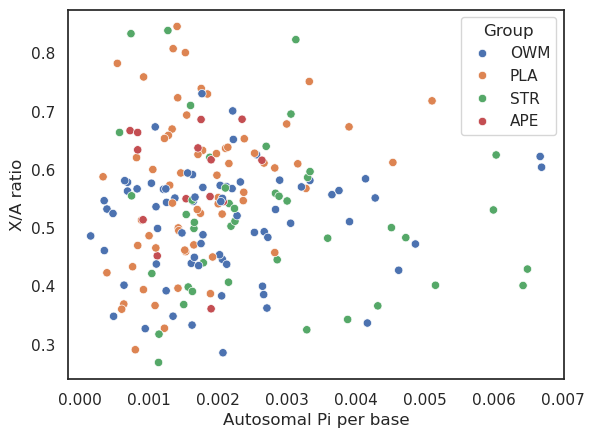

In [25]:
sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="X/A ratio", hue="Group")

In [26]:
filt_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "aut"]
filt_pi_df_chrx = filt_pi_df.loc[filt_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (filt_pi_df_aut.groupby(["species"])[["pi"]].std() / filt_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
mean_pi_df["CV_x"] = (filt_pi_df_chrx.groupby(["species"])[["pi"]].std() / filt_pi_df_chrx.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]

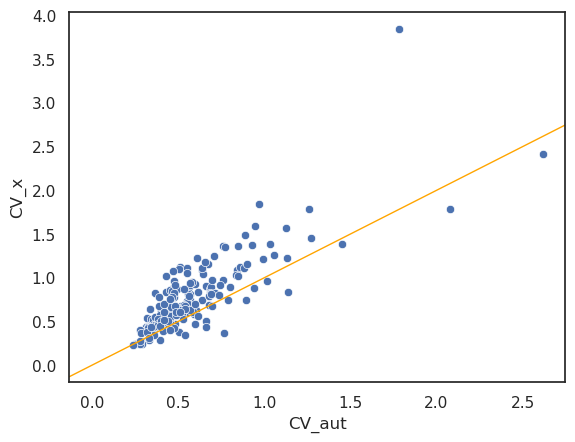

In [27]:
g = sns.scatterplot(mean_pi_df, x="CV_aut", y="CV_x")
plt.axline((0, 0), slope=1, linewidth=1, color='orange')

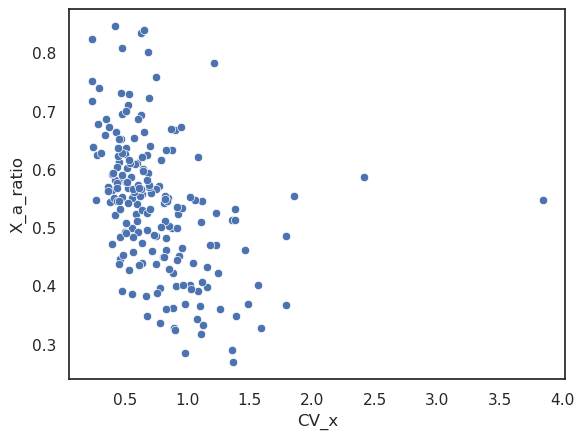

In [62]:
g = sns.scatterplot(mean_pi_df, y="X_a_ratio", x="CV_x")

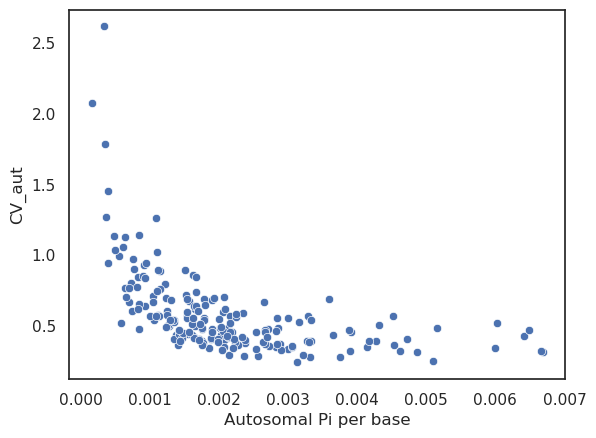

In [67]:
g = sns.scatterplot(mean_pi_df, x="Autosomal Pi per base", y="CV_aut")

In [79]:
mean_pi_df

chr_type,species,aut,chrX,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,CV_aut,CV_x,CV_difference,strategy
0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.001380,0.000761,0.551049,0.551049,Allenopithecus_nigroviridis,0.429124,0.842548,0.413424,Polygynandrous
1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.002712,0.000983,0.362366,0.362366,Allochrocebus_lhoesti,0.471371,0.883453,0.412082,Polygynous
2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.002649,0.001059,0.399758,0.399758,Allochrocebus_preussi,0.663639,0.907065,0.243427,Polygynous
3,Alouatta_belzebul_ssp,510.169378,366.218989,0.005102,0.003662,0.717838,0.717838,Alouatta_belzebul,0.249125,0.238095,-0.011030,Polygynous
4,Alouatta_discolor_ssp,206.429698,108.086733,0.002064,0.001081,0.523601,0.523601,Alouatta_discolor,0.591447,0.587333,-0.004113,Polygynous
...,...,...,...,...,...,...,...,...,...,...,...,...
188,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.001108,0.000594,0.536183,0.536183,Trachypithecus_pileatus,0.744030,0.915198,0.171168,Polygynous
189,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.000655,0.000380,0.580929,0.580929,Trachypithecus_poliocephalus,0.698364,0.678975,-0.019388,NaN
190,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.002328,0.001347,0.578665,0.578665,Trachypithecus_vetulus,0.418915,0.515573,0.096657,NaN
191,Varecia_variegata_ssp,211.144432,120.002801,0.002111,0.001200,0.568345,0.568345,Varecia_variegata,0.421419,0.614303,0.192884,NaN


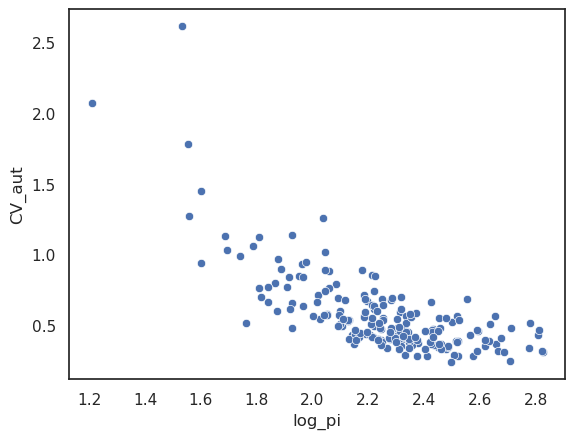

In [83]:
mean_pi_df["log_pi"] = np.log10(mean_pi_df["aut"])
g = sns.scatterplot(mean_pi_df, x="log_pi", y="CV_aut")

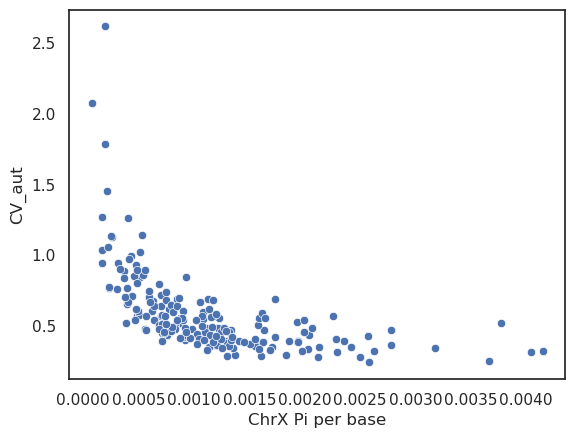

In [69]:
g = sns.scatterplot(mean_pi_df, x="ChrX Pi per base", y="CV_aut")

<Axes: xlabel='CV_aut', ylabel='Count'>

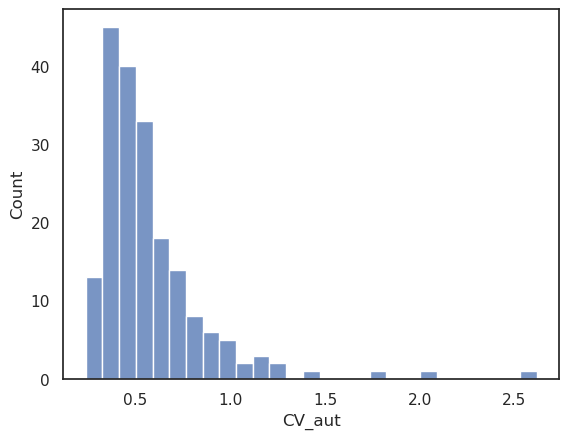

In [29]:
sns.histplot(mean_pi_df, x="CV_aut")

<Axes: xlabel='CV_x', ylabel='Count'>

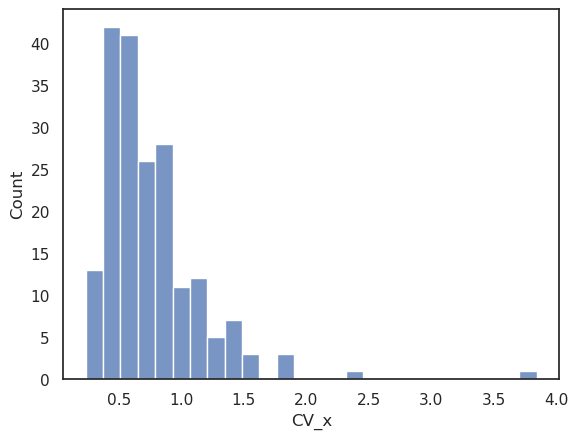

In [30]:
sns.histplot(mean_pi_df, x="CV_x")

<Axes: xlabel='CV_difference', ylabel='Count'>

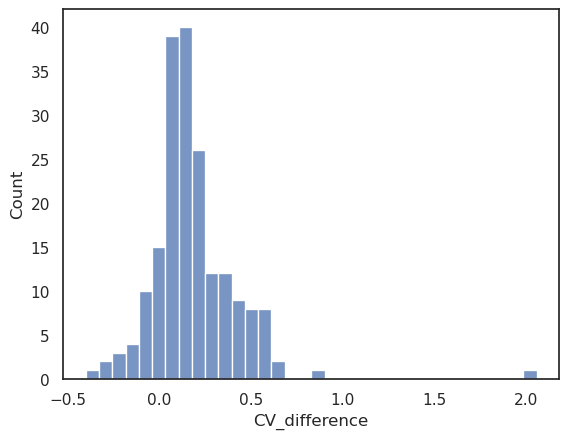

In [31]:
mean_pi_df["CV_difference"] = mean_pi_df.CV_x-mean_pi_df.CV_aut
sns.histplot(mean_pi_df, x="CV_difference")

In [32]:
mean_pi_df

chr_type,index,species,aut,chrX,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,Group,CV_aut,CV_x,CV_difference
0,0,Allenopithecus_nigroviridis_ssp,138.049579,76.072058,0.001380,0.000761,0.551049,0.551049,OWM,0.429124,0.842548,0.413424
1,1,Allochrocebus_lhoesti_ssp,271.244663,98.289917,0.002712,0.000983,0.362366,0.362366,OWM,0.471371,0.883453,0.412082
2,2,Allochrocebus_preussi_ssp,264.850665,105.876125,0.002649,0.001059,0.399758,0.399758,OWM,0.663639,0.907065,0.243427
3,3,Alouatta_belzebul_ssp,510.169378,366.218989,0.005102,0.003662,0.717838,0.717838,PLA,0.249125,0.238095,-0.011030
4,4,Alouatta_discolor_ssp,206.429698,108.086733,0.002064,0.001081,0.523601,0.523601,PLA,0.591447,0.587333,-0.004113
...,...,...,...,...,...,...,...,...,...,...,...,...
188,188,Trachypithecus_pileatus_ssp,110.758378,59.386733,0.001108,0.000594,0.536183,0.536183,OWM,0.744030,0.915198,0.171168
189,189,Trachypithecus_poliocephalus_ssp,65.467857,38.032207,0.000655,0.000380,0.580929,0.580929,OWM,0.698364,0.678975,-0.019388
190,190,Trachypithecus_vetulus_ssp,232.827177,134.729050,0.002328,0.001347,0.578665,0.578665,OWM,0.418915,0.515573,0.096657
191,191,Varecia_variegata_ssp,211.144432,120.002801,0.002111,0.001200,0.568345,0.568345,STR,0.421419,0.614303,0.192884


In [33]:
mean_pi_df.CV_aut.mean(), mean_pi_df.CV_x.mean(), mean_pi_df.CV_difference.mean()

(0.5746439862657515, 0.758713179987183, 0.18406919372143152)

In [34]:
import numpy as np
from scipy import stats
diff_df = mean_pi_df.loc[~mean_pi_df.CV_difference.isna()]
stats.ttest_rel(diff_df.CV_aut, diff_df.CV_x)

TtestResult(statistic=-10.681214184246302, pvalue=3.357096396186051e-21, df=192)

In [35]:
mean_per_chrom = filt_pi_df.groupby(["species", "chr_type", "chrom"])["pi"].mean().reset_index()

In [36]:
# Credit to Vasili Pankratov for consolidating this data
mating_vas = pd.read_excel("../data/PrimatePhenotypes_december.xlsx", sheet_name=8)
mating_vas

,binomial_name,Monogamous,Polygynous,Polygynandrous,Polyandrous,lowSC,highSC,consensus,comment,Juliana_Christina,genus_comment
0,Allenopithecus_nigroviridis,0,0,1,0,0,1,Polygynandrous,NaN,NaN,NaN
1,Allocebus_trichotis,2,1,0,0,3,0,Monogamous,NaN,NaN,NaN
2,Allochrocebus_lhoesti,0,3,0,0,3,0,Polygynous,NaN,NaN,NaN
3,Allochrocebus_preussi,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
4,Allochrocebus_solatus,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
311,Trachypithecus_phayrei,0,2,1,0,2,1,NaN,conflicting,NaN,NaN
312,Trachypithecus_pileatus,0,2,0,0,2,0,Polygynous,NaN,NaN,NaN
313,Trachypithecus_selangorensis,0,1,0,0,1,0,Polygynous,NaN,NaN,NaN
314,Varecia_rubra,0,1,1,0,1,1,NaN,conflicting,NaN,NaN


In [61]:
filt_pi_df.loc[filt_pi_df.species == "Gorilla_gorilla_ssp"].groupby(["species", "chrom"])["pi"].apply(lambda x: x.autocorr(lag=1)).reset_index()

,species,chrom,pi
0,Gorilla_gorilla_ssp,NC_073224.2,0.603243
1,Gorilla_gorilla_ssp,NC_073227.2,0.599215
2,Gorilla_gorilla_ssp,NC_073228.2,0.636907
3,Gorilla_gorilla_ssp,NC_073229.2,0.493563
4,Gorilla_gorilla_ssp,NC_073230.2,0.675003
5,Gorilla_gorilla_ssp,NC_073231.2,0.662505
6,Gorilla_gorilla_ssp,NC_073232.2,0.679510
7,Gorilla_gorilla_ssp,NC_073233.2,0.677812
8,Gorilla_gorilla_ssp,NC_073234.2,0.589811
9,Gorilla_gorilla_ssp,NC_073235.2,0.705807


In [37]:
mean_pi_df = filt_pi_df.loc[(filt_pi_df.species.isin(species_list))].groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["binomial_name"] = [x[:-4] for x in mean_pi_df.index]
filt_pi_df_aut = filt_pi_df.loc[filt_pi_df.chr_type == "aut"]
filt_pi_df_chrx = filt_pi_df.loc[filt_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (filt_pi_df_aut.groupby(["species"])[["pi"]].std() / filt_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
mean_pi_df["CV_x"] = (filt_pi_df_chrx.groupby(["species"])[["pi"]].std() / filt_pi_df_chrx.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
mean_pi_df["CV_difference"] = mean_pi_df.CV_x-mean_pi_df.CV_aut
mean_pi_df["strategy"] = mean_pi_df.binomial_name.map(dict(zip(mating_vas.binomial_name, mating_vas.consensus)))

In [38]:
mean_pi_df.groupby(["strategy"])[["Autosomal Pi per base", "X/A ratio", "CV_difference"]].mean()

chr_type,Autosomal Pi per base,X/A ratio,CV_difference
strategy,,,
Monogamous,0.001878,0.569853,0.157552
Polyandrous,0.004514,0.500326,0.223039
Polygynandrous,0.001941,0.522761,0.220333
Polygynous,0.002430,0.527080,0.179383


<Axes: xlabel='CV_difference', ylabel='Proportion'>

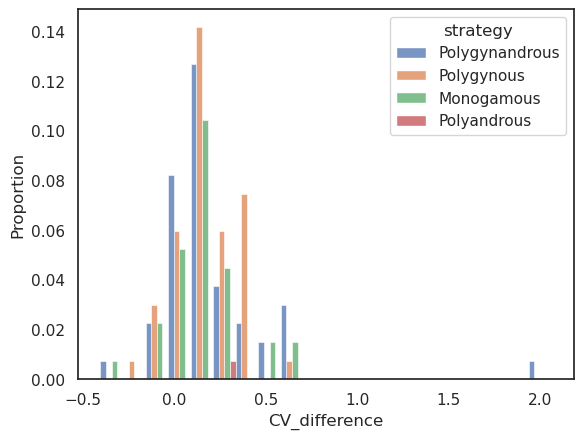

In [39]:
sns.histplot(mean_pi_df, x="CV_difference", hue="strategy", stat="proportion", multiple="dodge", bins=20)

In [40]:
mean_pi_df.loc[mean_pi_df.CV_difference >= 1]

chr_type,species,aut,chrX,Autosomal Pi per base,ChrX Pi per base,X_a_ratio,X/A ratio,binomial_name,CV_aut,CV_x,CV_difference,strategy
106,Macaca_sylvanus_ssp,35.721099,19.52448,0.000357,0.000195,0.546581,0.546581,Macaca_sylvanus,1.783211,3.842458,2.059247,Polygynandrous


In [41]:
filt_pi_df.loc[(filt_pi_df.species.isin(["Macaca_sylvanus_ssp"]))].groupby(["chrom"])[["pi"]].std()/filt_pi_df.loc[(filt_pi_df.species.isin(["Macaca_sylvanus_ssp"]))].groupby(["chrom"])[["pi"]].mean()

,pi
chrom,
NC_041754.1,1.996766
NC_041755.1,1.095857
NC_041756.1,1.888563
NC_041757.1,1.211120
NC_041758.1,1.282323
NC_041759.1,1.530721
NC_041760.1,1.936463
NC_041761.1,2.728488
NC_041762.1,1.232588


The CV for autosomes is slightly inflated due to adding different chromosomes together, but its not enough that I think its an issue.

In [42]:
df_l = []
fail_l = []
for s in all_pi_df.species.unique():
    s_df = filt_pi_df.loc[filt_pi_df.species == s]
    chrX_size = len(s_df.loc[s_df.chr_type == "chrX"])
    chrX_name = s_df.loc[s_df.chr_type == "chrX"].chrom.unique()
    sorted_sizes = s_df.loc[s_df.chr_type != "chrX"].groupby(["chrom"])[["species"]].count().reset_index().sort_values(by="species", ascending=False)
    similar_chrom_name = sorted_sizes.loc[sorted_sizes.species < chrX_size].chrom.iloc[0]
    try:
        chrX_df = s_df.loc[s_df.chr_type == "chrX"].copy()
        chrX_df["quartile"] = pd.qcut(chrX_df.pi, 4 , labels=False)
        aut_df = s_df.loc[s_df.chrom == similar_chrom_name].copy()
        aut_df["quartile"] = pd.qcut(aut_df.pi, 4 , labels=False)
    except:
        print(s)
        fail_l.append(s)
        continue
    chrX_df_group = chrX_df.groupby(["quartile"])[["pi"]].mean()
    aut_df_group = aut_df.groupby(["quartile"])[["pi"]].mean()
    out_df = pd.DataFrame({"quartiles": aut_df_group.index, "aut_quartile_means": aut_df_group.pi,
                          "chrX_quartile_means": chrX_df_group.pi})
    out_df["quartile_ratio"] = out_df["chrX_quartile_means"]/out_df["aut_quartile_means"]
    out_df["species"] = s
    df_l.append(out_df)
quartile_ratio_df = pd.concat(df_l)

Alouatta_palliata_ssp
Macaca_sylvanus_ssp


<Axes: xlabel='quartiles', ylabel='quartile_ratio'>

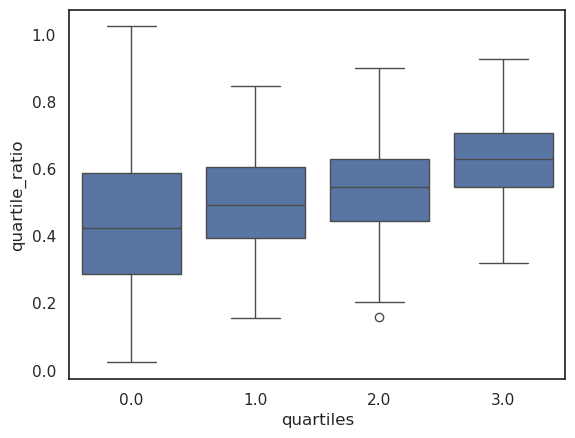

In [43]:
sns.boxplot(quartile_ratio_df, x="quartiles", y="quartile_ratio")

In [44]:
quartile_ratio_df.loc[quartile_ratio_df.quartile_ratio > 0.9]

,quartiles,aut_quartile_means,chrX_quartile_means,quartile_ratio,species
quartile,,,,,
3.0,3.0,181.761148,166.582920,0.916494,Cacajao_calvus_ssp
2.0,2.0,170.007077,153.358434,0.902071,Aotus_griseimembra_ssp
3.0,3.0,252.424847,233.943284,0.926784,Aotus_griseimembra_ssp
0.0,0.0,65.064286,62.356250,0.958379,Hapalemur_meridionalis_ssp
0.0,0.0,21.493506,22.020576,1.024522,Indri_indri_ssp


In [45]:
quartile_ratio_df.loc[quartile_ratio_df.quartile_ratio < 0.1]

,quartiles,aut_quartile_means,chrX_quartile_means,quartile_ratio,species
quartile,,,,,
0.0,0.0,170.285073,14.715147,0.086415,Microcebus_murinus_ssp
0.0,0.0,198.067061,5.308140,0.026800,Lepilemur_septentrionalis_ssp
0.0,0.0,95.712515,4.903571,0.051232,Eulemur_coronatus_ssp
0.0,0.0,115.595238,5.672932,0.049076,Cheirogaleus_sibreei_ssp
0.0,0.0,288.787105,21.651214,0.074973,Eulemur_sanfordi_ssp
0.0,0.0,89.848797,3.922330,0.043655,Microcebus_tavaratra_ssp
0.0,0.0,26.039683,2.563464,0.098445,Mirza_zaza_ssp
0.0,0.0,63.758410,1.479167,0.023200,Cheracebus_torquatus_ssp
0.0,0.0,25.922902,1.965021,0.075802,Pithecia_mittermeieri_ssp


In [46]:
quartile_ratio_df.loc[quartile_ratio_df.species == "Gorilla_gorilla_ssp"]

,quartiles,aut_quartile_means,chrX_quartile_means,quartile_ratio,species
quartile,,,,,
0.0,0.0,102.887710,29.337540,0.285141,Gorilla_gorilla_ssp
1.0,1.0,170.069175,70.155464,0.412511,Gorilla_gorilla_ssp
2.0,2.0,217.872982,124.397650,0.570964,Gorilla_gorilla_ssp
3.0,3.0,296.124156,194.746715,0.657652,Gorilla_gorilla_ssp


In [47]:
quartile_ratio_df.loc[quartile_ratio_df.species == "Indri_indri_ssp"]

,quartiles,aut_quartile_means,chrX_quartile_means,quartile_ratio,species
quartile,,,,,
0.0,0.0,21.493506,22.020576,1.024522,Indri_indri_ssp
1.0,1.0,239.775862,102.546218,0.427675,Indri_indri_ssp
2.0,2.0,448.497817,205.162500,0.457444,Indri_indri_ssp
3.0,3.0,713.298701,364.325000,0.510761,Indri_indri_ssp


In [48]:
stats.ttest_rel(quartile_ratio_df.loc[quartile_ratio_df.quartiles == 0].quartile_ratio,
                quartile_ratio_df.loc[quartile_ratio_df.quartiles == 3].quartile_ratio)

TtestResult(statistic=-13.16668094395205, pvalue=1.4778728335847973e-28, df=190)

<Axes: xlabel='quartile_ratio', ylabel='Count'>

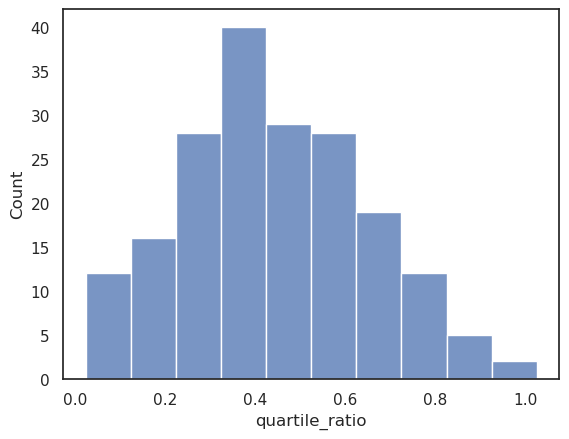

In [49]:
sns.histplot(quartile_ratio_df.loc[quartile_ratio_df.quartiles == 0], x="quartile_ratio")

In [50]:
s_df.groupby(["chrom"])[["species"]].count().reset_index().sort_values(by="species", ascending=False)

,chrom,species
0,CM058074.1,1973
1,CM058075.1,1863
2,CM058076.1,1737
3,CM058077.1,1719
4,CM058078.1,1706
6,CM058080.1,1545
22,CM058096.1,1487
7,CM058081.1,1478
5,CM058079.1,1423
8,CM058082.1,1375


In [51]:
chrX_size

1487

In [52]:
# Implementation to check for streaks of low diversity.
for s in all_pi_df.species.unique()[:1]:
    s_df = all_pi_df.loc[all_pi_df.species == s]
    print(s)
    for c in s_df.chrom.unique():
        c_df = s_df.loc[(s_df.chrom == c) & (s_df.callable_frac >= 0.5)].copy()
        try:
            c_df["quartile"] = pd.qcut(c_df.pi, [0, 0.5, 1] , labels=False)
        except:
            print(c)
            continue
        k = 0
        k_list = []
        for q in c_df.quartile:
            if q == 0:
                k = k+1
            else:
                k = max(0, k-5)
            k_list.append(k)
        print(c, max(k_list))

Macaca_fascicularis_ssp
CP141361.1 98
CP141360.1 123
CP141359.1 65
CP141358.1 41
CP141357.1 66
CP141356.1 127
CP141355.1 81
CP141354.1 128
CP141353.1 95
CP141352.1 69
CP141351.1 51
CP141350.1 87
CP141349.1 115
CP141348.1 60
CP141347.1 92
CP141346.1 92
CP141345.1 26
CP141344.1 46
CP141343.1 28
CP141342.1 41
CP141341.1 81
